<a href="https://colab.research.google.com/github/mathangivs22/FAIProject/blob/main/ML_LearningInsurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('insurance.csv')

In [4]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


#EDA

In [5]:
df.shape

(1338, 7)

In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


#Extract numeric values

In [10]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

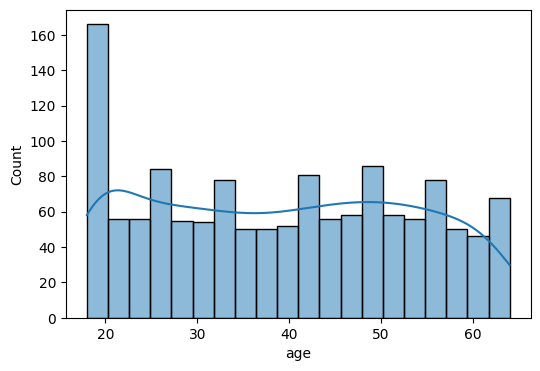

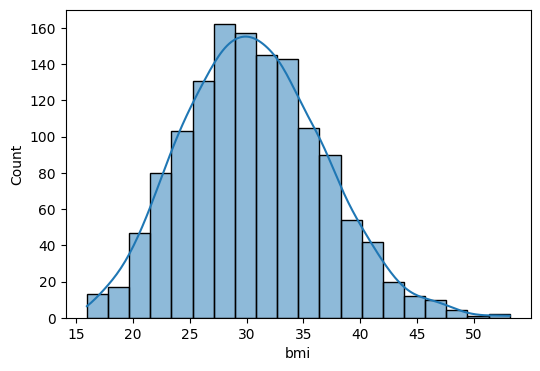

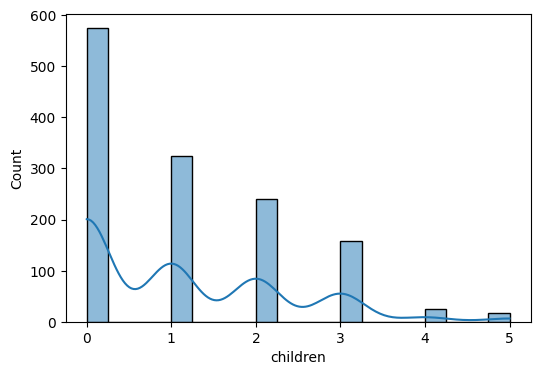

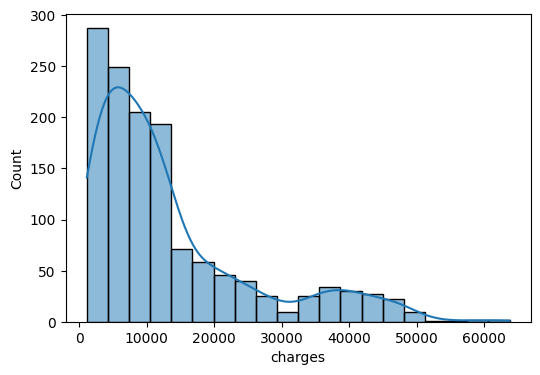

In [11]:
numeric_columns = ["age","bmi","children","charges"]
for col in numeric_columns:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col], kde=True,bins=20)


<Axes: xlabel='children', ylabel='count'>

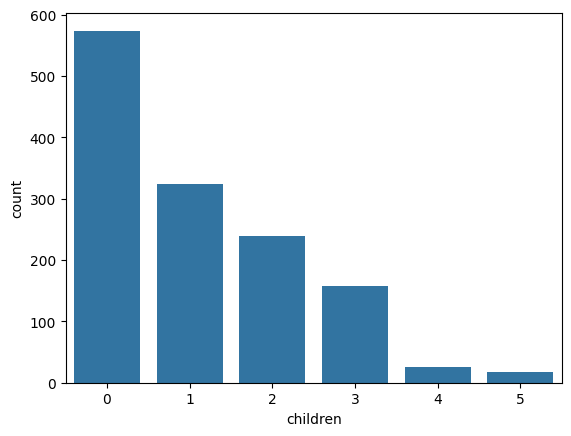

In [12]:
sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

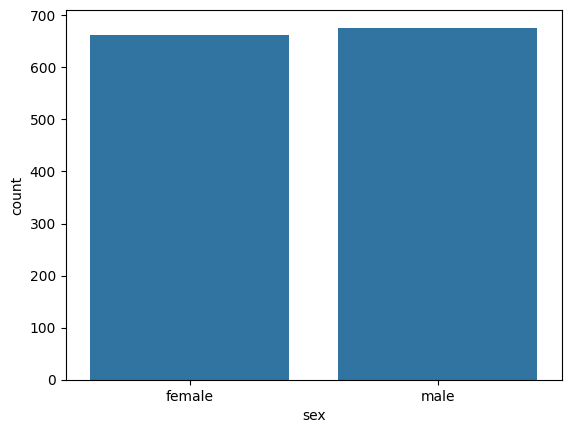

In [13]:
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

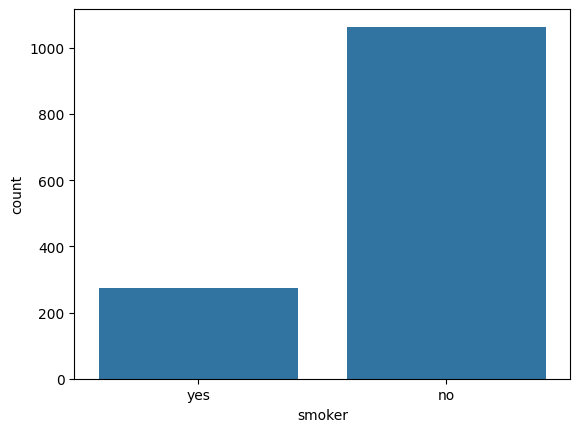

In [14]:
sns.countplot(x = df['smoker'])

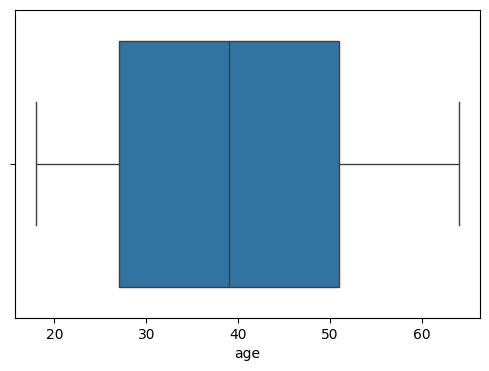

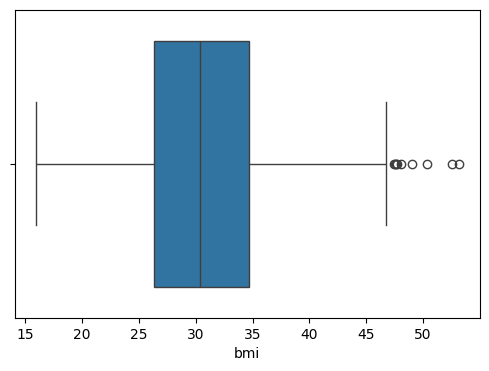

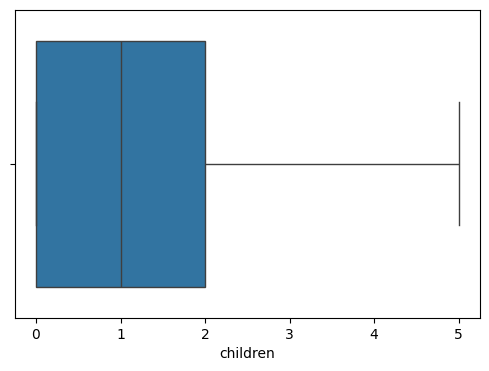

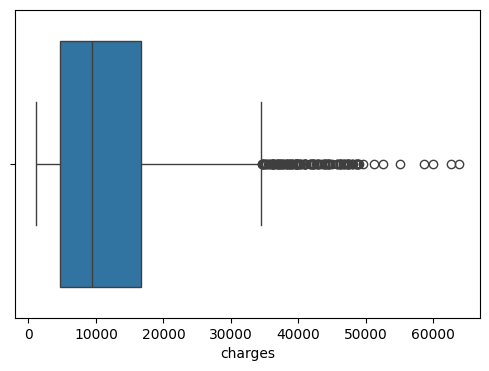

In [15]:
for col in numeric_columns:
  plt.figure(figsize =(6,4))
  sns.boxplot(x=df[col])

#Correlation Map

<Axes: >

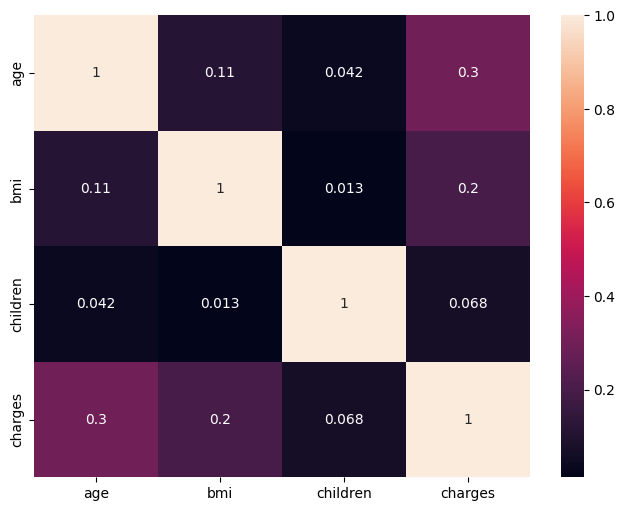

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

#Data cleaning and preprocessing

In [17]:
df_cleaned = df.copy()

In [18]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
df_cleaned.shape

(1338, 7)

In [20]:
df_cleaned.drop_duplicates(inplace=True)

In [21]:
df_cleaned.shape

(1337, 7)

In [22]:
df_cleaned.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


#Need to convert Objects to Integers(Label encoding!)

In [23]:
df_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [24]:
df_cleaned['sex'].value_counts()

,count
sex,
male,675
female,662


#Label Encoding

In [25]:
df_cleaned['sex'] = df_cleaned['sex'].map({"male":0,"female":1})

In [26]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [27]:
df_cleaned['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [28]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({"no":0,"yes":1})

In [29]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [30]:
df_cleaned.rename(columns={'sex':'is_female' ,'smoker':'is_smoker'},inplace="True")

In [31]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


# One hot encoding

In [32]:
df_cleaned['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [33]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['region'],drop_first=True)

In [34]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')

In [35]:
df_cleaned = df_cleaned.astype(int)

In [36]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


#Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

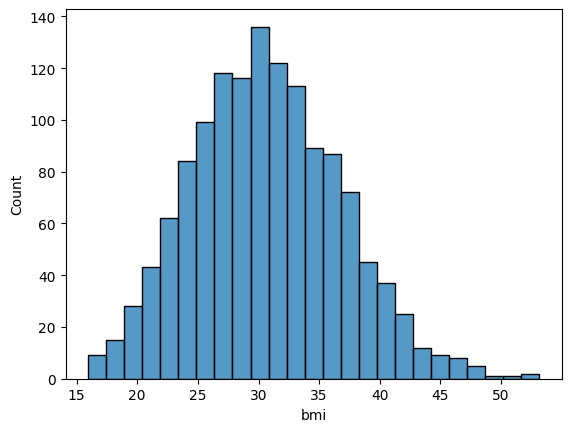

In [37]:
sns.histplot(df['bmi'])

In [38]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['Underweight','Normal','Overweight','Obese']
)

In [39]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,Obese
1334,18,1,31,0,0,2205,0,0,0,Obese
1335,18,1,36,0,0,1629,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,1,Overweight


# Now we have bmi_category as Overweight ,Obese ,Normal need to convert it into 1 and 0

In [40]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['bmi_category'],drop_first=True)

In [41]:
df_cleaned = df_cleaned.astype(int)

In [42]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


#Feature Scaling

In [43]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [44]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

# Only numeric values need to be modified rest are as 0 or 1

In [45]:
from sklearn.preprocessing import StandardScaler
cols =['age','bmi','children']
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [46]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


#Feature Extraction

In [47]:
from scipy.stats import pearsonr
#Pearson correlation
selected_features =['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese']

correlations = {feature:pearsonr(df_cleaned[feature],df_cleaned['charges'])[0]
                for feature in selected_features
                }
correlations_df =pd.DataFrame(list(correlations.items()),columns=['Feature','Pearson Correlation'])
correlations_df.sort_values(by='Pearson Correlation',ascending =False)

,Feature,Pearson Correlation
5,charges,1.000000
4,is_smoker,0.787234
0,age,0.298309
11,bmi_category_Obese,0.200348
2,bmi,0.196236
7,region_southeast,0.073577
3,children,0.067390
6,region_northwest,-0.038695
8,region_southwest,-0.043637
1,is_female,-0.058046


In [48]:
#Correlation always btw 0 to 1 only. High value +ve means highly correalted freatures.
#Those below 0.5 they can be neglected.


#ChiSquare TEST

In [49]:
cat_features = ['is_female','is_smoker','region_northwest','region_southwest',
'region_southeast','bmi_category_Normal','bmi_category_Obese','bmi_category_Overweight']

In [50]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha =0.05

#Create bins means small intervals of the part
df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'],q=4,labels =False)
chi2_results ={}

# 3. Perform chi-square test for each feature
for feature in cat_features:

    # Create contingency table
    table = pd.crosstab(df_cleaned[feature], df_cleaned['charges_bin'])

    # Chi-square test
    chi2, p, dof, expected = chi2_contingency(table)

    # Decision Rule
    decision = "Reject H0 (Significant Association)" if p < alpha else "Fail to Reject H0 (No Significant Association)"

    chi2_results[feature] = {
        'chi2': round(chi2, 3),
        'p_value': round(p, 5),
        'decision': decision
    }

# 4. Create a dataframe for easy reading
chi2_df = pd.DataFrame.from_dict(chi2_results, orient='index')
chi2_df = chi2_df.sort_values(by='p_value')

chi2_df

,chi2,p_value,decision
is_smoker,848.219,0.00000,Reject H0 (Significant Association)
region_southeast,15.998,0.00113,Reject H0 (Significant Association)
is_female,10.259,0.01649,Reject H0 (Significant Association)
bmi_category_Obese,8.516,0.03647,Reject H0 (Significant Association)
region_southwest,5.092,0.16519,Fail to Reject H0 (No Significant Association)
bmi_category_Overweight,4.251,0.23556,Fail to Reject H0 (No Significant Association)
bmi_category_Normal,3.708,0.29476,Fail to Reject H0 (No Significant Association)
region_northwest,1.134,0.76882,Fail to Reject H0 (No Significant Association)


In [51]:
final_df = df_cleaned[['age','is_female','charges','is_smoker','region_southeast','bmi_category_Obese']]

In [52]:
final_df.head()


,age,is_female,charges,is_smoker,region_southeast,bmi_category_Obese
0,-1.440418,1,16884,1,0,0
1,-1.511647,0,1725,0,1,1
2,-0.799350,0,4449,0,1,1
3,-0.443201,0,21984,0,0,0
4,-0.514431,0,3866,0,0,0


In [53]:
#Models
from sklearn.model_selection import train_test_split

# Features and target
X = df_cleaned.drop(['charges', 'charges_bin'], axis=1)
y = df_cleaned['charges']

# Convert categorical variables
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [54]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

In [55]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

In [56]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Linear Regression Metrics
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = mean_squared_error(y_test, y_pred_lr) ** 0.5
lr_r2 = r2_score(y_test, y_pred_lr)

# Random Forest Metrics
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = mean_squared_error(y_test, y_pred_rf) ** 0.5
rf_r2 = r2_score(y_test, y_pred_rf)

# Comparison Table
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})

print(comparison)

               Model          MAE         RMSE  R2 Score
0  Linear Regression  4305.542208  5991.146647  0.804666
1      Random Forest  2752.234140  4756.556234  0.876876


In [57]:
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                    Feature  Importance
4                 is_smoker    0.601070
0                       age    0.143845
2                       bmi    0.107108
10       bmi_category_Obese    0.082194
3                  children    0.025811
1                 is_female    0.009943
5          region_northwest    0.009065
6          region_southeast    0.008464
7          region_southwest    0.006175
9   bmi_category_Overweight    0.003200


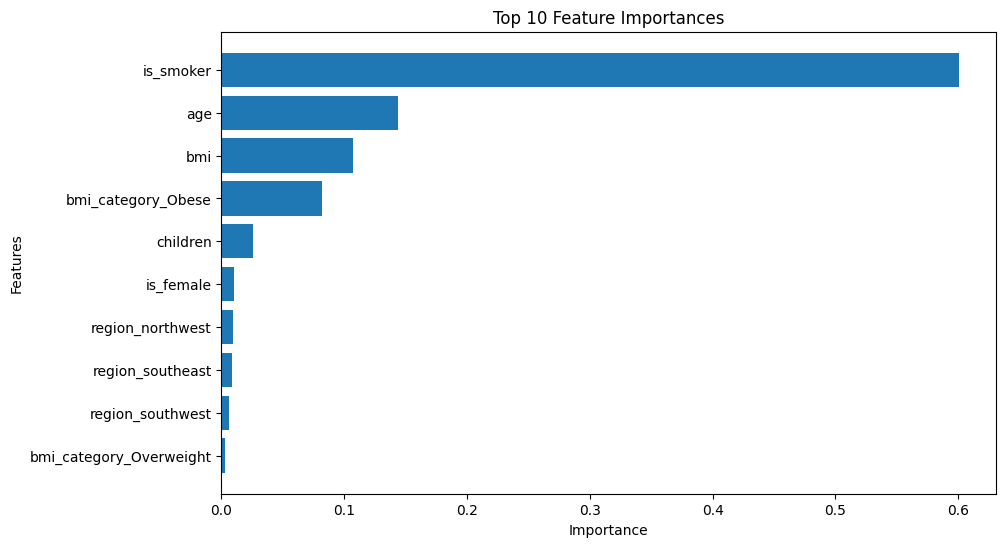

In [58]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Feature Importances")

plt.gca().invert_yaxis()

plt.show()

In [59]:
residuals = y_test - y_pred_lr

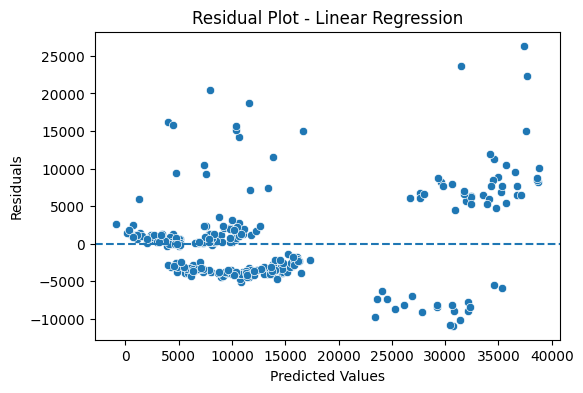

In [60]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.scatterplot(
    x=y_pred_lr,
    y=residuals
)

plt.axhline(0, linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")

plt.show()

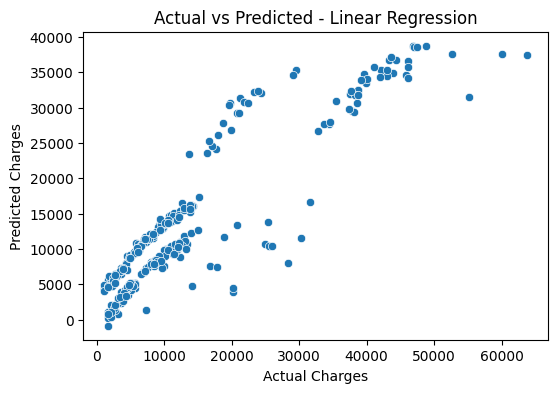

In [61]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=y_test,
    y=y_pred_lr
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted - Linear Regression")

plt.show()